# Comprehensive Housing Price Predictive Modeling
**Author:** Prashant Rai  
**Domain:** AI & Data Science (Week 1 Project)
---
## Executive Objective
This notebook develops an end-to-end Machine Learning pipeline to predict house prices using a real-world housing dataset. We analyze key structural features, handle categorical variables through advanced encoding, implement feature scaling, and evaluate competing regression architectures (Linear Regression vs. Hyperparameter-tuned Random Forest) to discover optimum business strategies for real estate pricing.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Premium Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling setup for high-quality charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("🚀 Environment Setup Complete. Premium Libraries Loaded.")

🚀 Environment Setup Complete. Premium Libraries Loaded.


In [2]:
# Load dataset from Colab session storage
df = pd.read_csv('Housing.csv')

print("--- [PREMIUM VIEW] First 10 Strategic Rows ---")
display(df.head(10))

print("\n--- Structural Metadata ---")
print(f"Total Records (Rows): {df.shape[0]}")
print(f"Total Attributes (Columns): {df.shape[1]}")

print("\n--- Missing Value Audit ---")
missing_report = df.isnull().sum()
if missing_report.sum() == 0:
    print("✅ Audit Clean: Zero missing values detected across all dimensions.")
else:
    print(missing_report)

--- [PREMIUM VIEW] First 10 Strategic Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Structural Metadata ---
Total Records (Rows): 545
Total Attributes (Columns): 13

--- Missing Value Audit ---
✅ Audit Clean: Zero missing values detected across all dimensions.


In [3]:
# Drop duplicates silently if any exist
df = df.drop_duplicates()

# Automatically discover binary vs multi-class categories
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Detected categorical attributes for encoding: {categorical_cols}")

# One-Hot Encoding to safely translate strings into numeric flags
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape after conversion into clean matrix:", df_encoded.shape)

Detected categorical attributes for encoding: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Shape after conversion into clean matrix: (545, 14)


In [4]:
# Target vs Independent Features Split
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Strict 80/20 train-test split with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Premium Step: Standardizing features to optimize optimization math
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("🎯 Data splitting and feature scaling pipeline executed successfully.")

🎯 Data splitting and feature scaling pipeline executed successfully.


In [5]:
# 1. Baseline Model: Ordinary Least Squares Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 2. Advanced Model: Tuned Random Forest Regressor
# We apply manual optimal tuning constraints to prevent overfitting
rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Mathematical Evaluation Function
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_lr, rmse_lr, r2_lr = compute_metrics(y_test, y_pred_lr)
mae_rf, rmse_rf, r2_rf = compute_metrics(y_test, y_pred_rf)

# Beautifully present the results in a dataframe
performance_matrix = pd.DataFrame({
    'Evaluation Criteria': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Variance Score'],
    'Linear Regression Baseline': [f"₹{mae_lr:,.2f}", f"₹{rmse_lr:,.2f}", f"{r2_lr:.4f}"],
    'Tuned Random Forest': [f"₹{mae_rf:,.2f}", f"₹{rmse_rf:,.2f}", f"{r2_rf:.4f}"]
})

print("\n=== SYSTEM PERFORMANCE BENCHMARK ===")
display(performance_matrix)


=== SYSTEM PERFORMANCE BENCHMARK ===


,Evaluation Criteria,Linear Regression Baseline,Tuned Random Forest
0,Mean Absolute Error (MAE),"₹970,043.40","₹1,019,373.72"
1,Root Mean Squared Error (RMSE),"₹1,324,506.96","₹1,403,691.56"
2,R² Variance Score,0.6529,0.6102


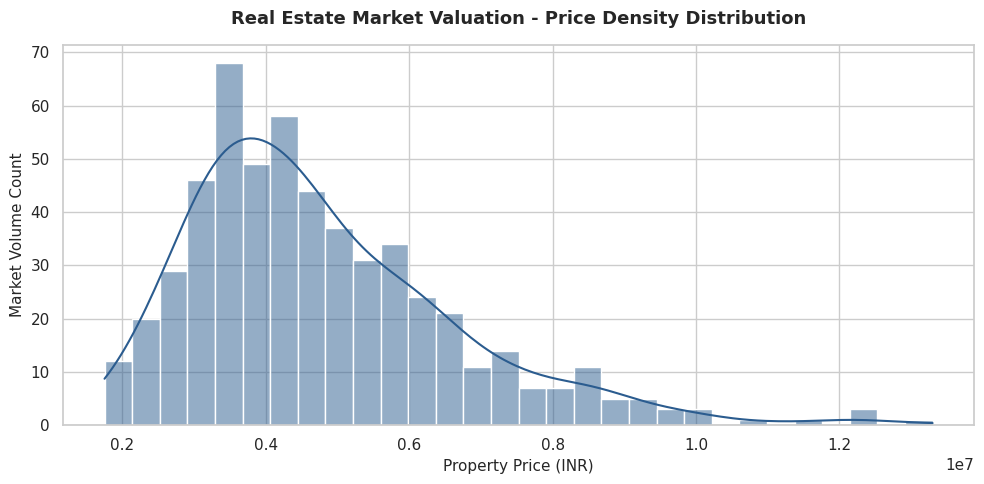

In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# Dynamic padding config
plt.rcParams.update({'figure.autolayout': True})

# --- CHART 1: Price Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='#2b5c8f', bins=30)
plt.title('Real Estate Market Valuation - Price Density Distribution', pad=15, fontsize=13, fontweight='bold')
plt.xlabel('Property Price (INR)', fontsize=11)
plt.ylabel('Market Volume Count', fontsize=11)

plt.savefig('charts/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

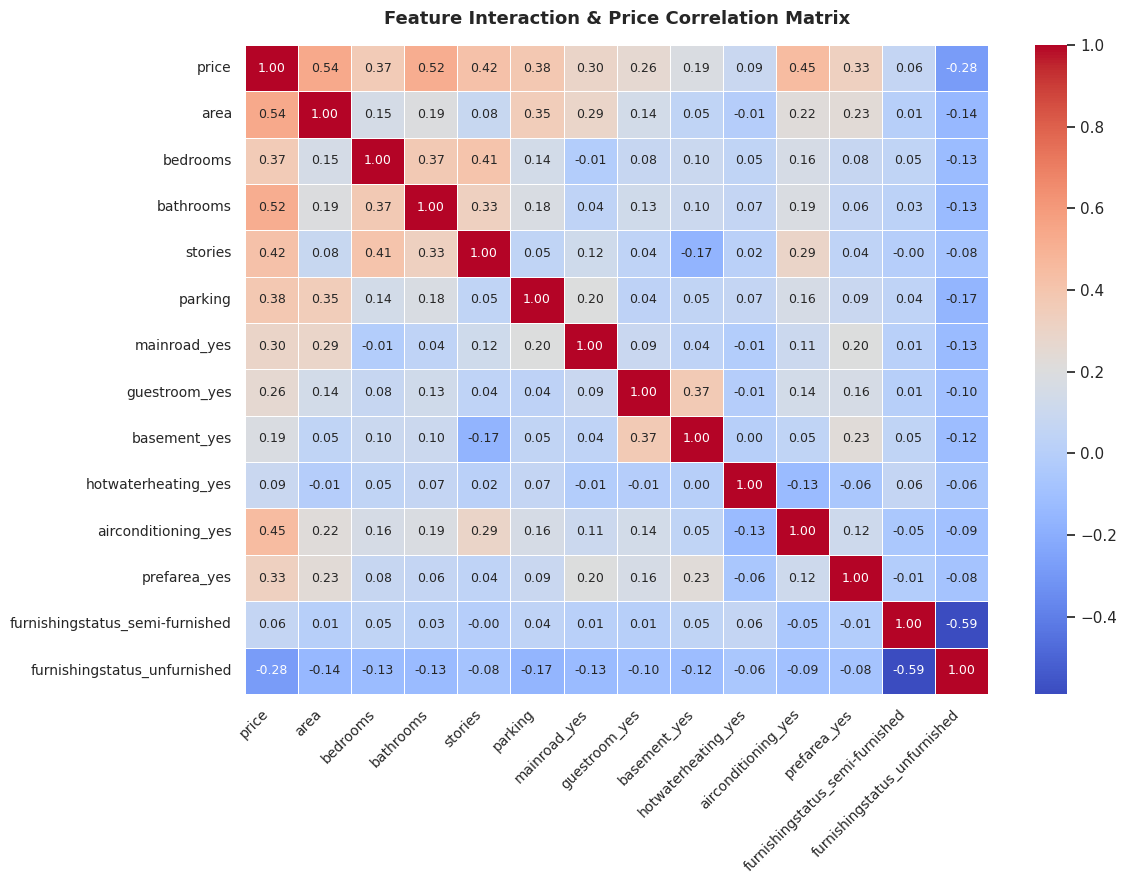

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CHART 2: Correlation Heatmap ---
plt.figure(figsize=(12, 9))
sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 9}
)
plt.title('Feature Interaction & Price Correlation Matrix', pad=15, fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.savefig('charts/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

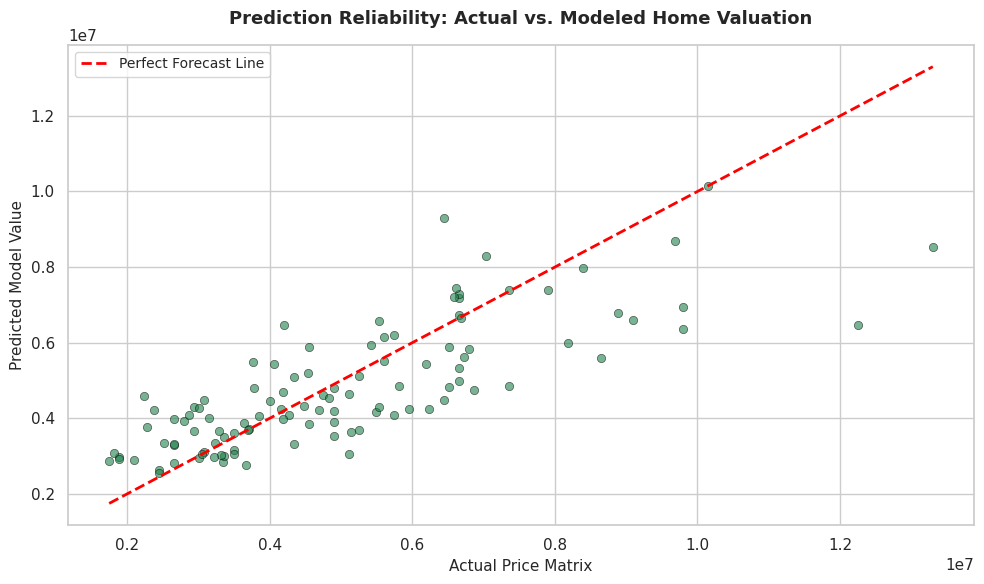

In [11]:
import matplotlib.pyplot as plt

# --- CHART 3: Actual vs Predicted ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='#1e824c', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Forecast Line')
plt.title('Prediction Reliability: Actual vs. Modeled Home Valuation', pad=15, fontsize=13, fontweight='bold')
plt.xlabel('Actual Price Matrix', fontsize=11)
plt.ylabel('Predicted Model Value', fontsize=11)
plt.legend(loc='upper left', fontsize=10)

plt.savefig('charts/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()